In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
#exploratory analysis
train.shape

(1460, 81)

In [5]:
test.shape

(1459, 80)

In [6]:
train.info

<bound method DataFrame.info of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Ut

In [7]:
#check missing values
missing_values = train.isnull().sum() #asks whether each value is missing and counts missing values
missing_values = missing_values[missing_values > 0] #only keep columnd that contain missing data
missing_values.sort_values(ascending=False) #puts columns with most missing values at top.

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [8]:
#data text description tells us Na means no fence, no pool etc
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

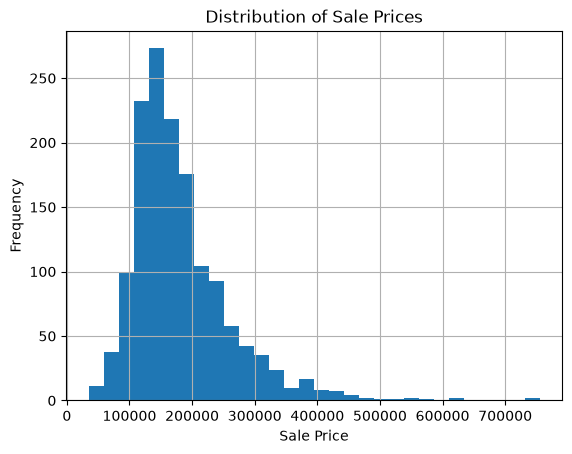

In [9]:
train["SalePrice"].hist(bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of Sale Prices")
plt.show()

In [10]:
#sale price is skewed to the right, log transformation can help normalise the data
log_sale_price = np.log1p(train["SalePrice"]) #log transformation

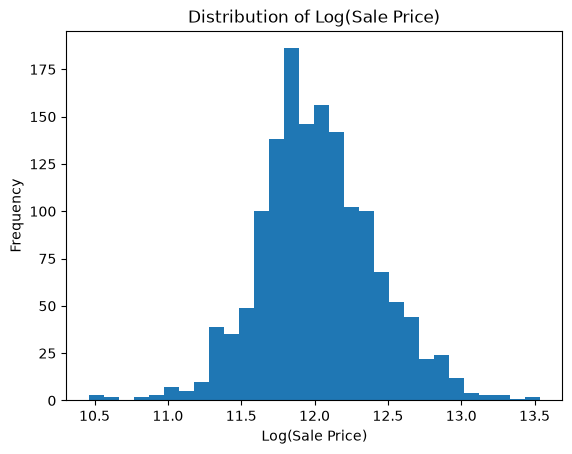

In [11]:
plt.hist(log_sale_price, bins=30)
plt.title("Distribution of Log(Sale Price)")
plt.xlabel("Log(Sale Price)")
plt.ylabel("Frequency")
plt.show()

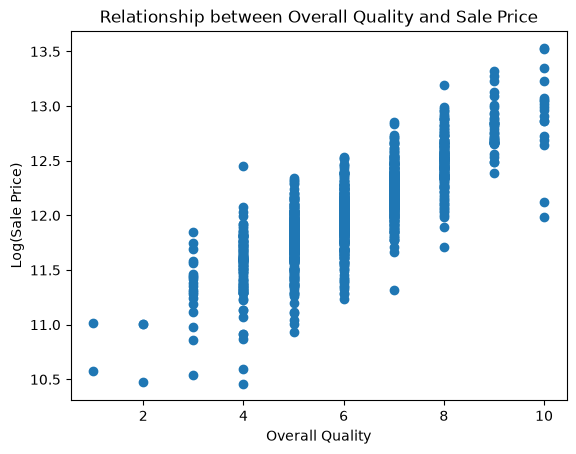

In [ ]:
# the log transformation compresses the higher sale prices, reducing right-skew and making the distribution more symmetric
#now what features are related to sale price?
plt.scatter(train["OverallQual"], log_sale_price)
plt.xlabel("Overall Quality")
plt.ylabel("Log(Sale Price)")
plt.title("Relationship between Overall Quality and Sale Price")
plt.show()


In [13]:
#positive relationship between overall quality and sale price, as overall quality increases, so does the sale price.
#Most observations are concentrated around quality scores of 4-8 while higher quality scores are less common with a slightly wider spread in sale prices.

correlation_data = pd.DataFrame({
    "OverallQual": train["OverallQual"],
    "LogSalePrice": log_sale_price
})

correlation_data.corr()

,OverallQual,LogSalePrice
OverallQual,1.000000,0.817185
LogSalePrice,0.817185,1.000000


In [14]:
#strong positive linear relationship with a correlation coefficient of of 0.82. Note correlation does not imply causation, but it does suggest that overall quality is a good predictor of sale price.
#check other numerical features for correlation with sale price
numeric_data = train.select_dtypes(include=["number"])

correlations = numeric_data.corr()["SalePrice"].sort_values(ascending=False)

correlations.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [15]:
#garage cars and area are probably related as a bigger garage can hold more cars.
train[["GarageCars", "GarageArea"]].corr()

,GarageCars,GarageArea
GarageCars,1.000000,0.882475
GarageArea,0.882475,1.000000


In [16]:
train[["GrLivArea", "1stFlrSF", "TotalBsmtSF"]].corr()

,GrLivArea,1stFlrSF,TotalBsmtSF
GrLivArea,1.000000,0.566024,0.454868
1stFlrSF,0.566024,1.000000,0.819530
TotalBsmtSF,0.454868,0.819530,1.000000


In [17]:
#first floor and total basement area are strongly correlated, likely due to the fact that houses with larger first floors also have larger basements. GrLivArea is less correlated with the other two features, but still has a positive correlation with both.
categorical_cols = train.select_dtypes(include=["object"]).columns

print("Number of categorical variables:", len(categorical_cols))
categorical_cols.tolist()

Number of categorical variables: 43


/var/folders/4v/85g4fpqs68d7nwx6_bgx8vch0000gn/T/ipykernel_32805/272829606.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=["object"]).columns


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [18]:
#start with an obvious predictor of house price, neighbourhood.
train["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [19]:
#tells us how many houses are in each neighbourhood. 

neighborhood_prices = (
    train.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

neighborhood_prices

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

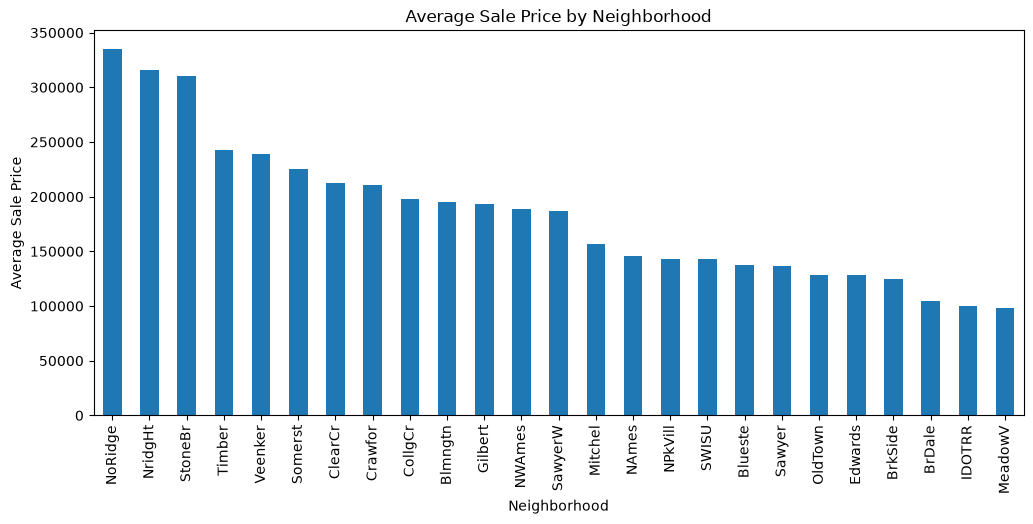

In [20]:
#this tells us the average sale price of houses in each neighbourhood. 

neighborhood_prices.plot(kind="bar", figsize=(12,5))

plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price")
plt.title("Average Sale Price by Neighborhood")
plt.xticks(rotation=90)
plt.show()

In [21]:
#the average sale price varies significantly across neighbourhoods suggesting location is an important indicator of house price. 


In [22]:

#turn the categorical variable into a numerical variable using one-hot encoding. This will create a new column for each category in the original column, with a 1 indicating the presence of that category and a 0 indicating its absence.

X = train.drop(columns=["SalePrice"])
y = np.log1p(train["SalePrice"])

In [23]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

Categorical columns: 43
Numerical columns: 37


/var/folders/4v/85g4fpqs68d7nwx6_bgx8vch0000gn/T/ipykernel_32805/2252255299.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [24]:
#build preprocessing using scikit-learn.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [25]:
X_simple = pd.get_dummies(X, drop_first=True)
#create dummy variables, dropping the first category to avoid multicollinearity.

In [26]:
X_simple.shape

(1460, 245)

In [27]:
X_simple = X_simple.fillna(X_simple.median()) #fill any remaining missing values with the median of each column. This is a simple imputation strategy that can help prevent errors during model training.

In [28]:
#split the data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
#build first model

model = LinearRegression()
model.fit(X_train, y_train) #mathematically finds the best-fitting line through the training data by minimizing the sum of squared errors between the predicted and actual values.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](245,)","[-0. ,-0. ,-0. ,..., 0.05, 0.07, 0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](245,)","['Id','MSSubClass','LotFrontage',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.67
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,245
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(235)


In [30]:
X_simple.isna().sum().sort_values(ascending=False).head(15) #check why regression wont run

Id                   0
ExterCond_Po         0
Foundation_CBlock    0
Foundation_PConc     0
Foundation_Slab      0
Foundation_Stone     0
Foundation_Wood      0
BsmtQual_Fa          0
BsmtQual_Gd          0
BsmtQual_TA          0
BsmtCond_Gd          0
BsmtCond_Po          0
BsmtCond_TA          0
BsmtExposure_Gd      0
BsmtExposure_Mn      0
dtype: int64

In [31]:
print("Missing in X_simple:", X_simple.isna().sum().sum())
print("Missing in X_train:", X_train.isna().sum().sum())
print("Missing in X_valid:", X_valid.isna().sum().sum())

Missing in X_simple: 0
Missing in X_train: 0
Missing in X_valid: 0


In [32]:
#continue builiding model

predictions = model.predict(X_valid) #takes the houses the model did not train on and asks the fitted regression model to predict log scale prices.


In [33]:
rmse = np.sqrt(mean_squared_error(y_valid, predictions)) #finds the error for each prediction, squares it, averages them.
print("RMSE:", rmse) #np.sqrt takes the square root which gives us RMSE (root mean squared error).
#lower RMSE indicates better model performance, we get an RMSE od 0.1485, which means the model is typically off by about 0.15 log units.

#The model achieved an RMSE of about 0.15 on the log-price scale. Since lower RMSE is better, I used that as my baseline and compared other models against it.

RMSE: 0.1484939096643583


In [34]:
train["SalePrice"].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [35]:
train["SalePrice"].min(), train["SalePrice"].max()

(np.int64(34900), np.int64(755000))

In [36]:
print(y_valid.head())
print(predictions[:5])

892     11.947956
1105    12.691584
413     11.652696
522     11.976666
1036    12.661917
Name: SalePrice, dtype: float64
[11.9283791  12.69159843 11.49582378 12.04072361 12.64010116]


In [37]:
#model comparison with simple forest regressor

from sklearn.ensemble import RandomForestRegressor

In [38]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [39]:
rf_predictions = rf_model.predict(X_valid)

In [40]:
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_predictions))
print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 0.14778686180725673


In [41]:
print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 0.1484939096643583
Random Forest RMSE: 0.14778686180725673


In [ ]:
#random forest is slightly better but not by much. 
#improves from 0.1485 to 0.1478, but the random forest model is more complex and takes longer to train. In this case, the linear regression model may be preferred due to its simplicity and interpretability.

X = train.drop(columns=["SalePrice"])
y = np.log1p(train["SalePrice"])

combined = pd.concat([X, test], axis=0)

combined = pd.get_dummies(combined, drop_first=True)
combined = combined.fillna(combined.median())

X_final = combined.iloc[:len(train)]
test_final = combined.iloc[len(train):] #for consistency, we need to apply the same preprocessing steps to the test data as we did to the training data.


In [43]:
final_model = LinearRegression()
final_model.fit(X_final, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](245,)","[-0. ,-0. ,-0. ,..., 0.03, 0.07,-0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](245,)","['Id','MSSubClass','LotFrontage',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,245
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(238)


In [44]:
#predictions on the test set
test_log_predictions = final_model.predict(test_final)

In [45]:
test_predictions = np.expm1(test_log_predictions)

In [46]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)

In [47]:
submission.head()

,Id,SalePrice
0,1461,116566.681515
1,1462,151735.313899
2,1463,172984.209238
3,1464,198315.834613
4,1465,198003.206519


Conclusion
The Linear Regression model achieved a validation RMSE of 0.1485 and a Kaggle score of 
0.1493. A Random Forest model produced only a marginal improvement on the validation set, so Linear Regression was retained as the preferred model due to its simplicity and interpretability.